In [1]:
import arviz as az
import math
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import scipy.stats as stats
import pandas as pd
import xarray as xr
from causalgraphicalmodels import CausalGraphicalModel

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
hdi_fill_args = { 'color': 'gray', 'alpha': 0.2 }

__Probabilistic Programming. Wasowski. Pardo. IT University of Copenhagen__

This file contains the list of exercises for the week, as well as any related code.

## Exercises

The exercises for this week are: all exercises from Chapter 6, McElreath, with exceptions noted below. Some remarks:
* __6E2__ refers to your past research. If no project makes sense, just try to recall which examples in the chapter were used to exemplify the selected problem (for better retention).
* __6M1__: As far as I can see there is no function to lists all paths with causalgraphicalmodels, but for backdoor paths there is: `get_all_backdoor_paths("X", "Y")`. The function `get_all_backdoor_adjustment_sets("X", "Y")` lists variable sets on which one can condition to ensure backdoors are closed. In Python, a `frozenset` is just an immutable set. You will see frozen sets occasionally from the library.

* Exercise __6M2__ does not use the causal graph library. You just need to sample some data with `scipy.stats` or `numpy.random`, and then analyze it again using PyMC. For instance: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html (use `rvs`) or https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html.

* Exercise __6H1__: the exercise asks (indirectly) to build a multiple regression model including northern and southern states, and check what is the posterior distribution of the parameter 'number of waffle houses'. Then compare it with regression without conditioning on the North/South. Note that the file with data is already in the data directory, and that there is a column `South` in it, which you can use as a regressor in your new model.

* Exercise __6H2__: you can use `get_all_independence_relationships` from the casual graph library (or better think about it first yourself, and then build the graph and check whether you agree with the library).

* The remaining exercises use a data set of foxes. Code to load it (the data is already in the right directory):

In [3]:
foxy = pd.read_csv("foxes.csv", delimiter=";").to_xarray()

* Exercise __6H3__: to infer the effect understand what variables one should (not) condition upon, and perform the regression.  Then check the parameter posterior for area.

* Exercise __6H4__ is similar to __6H3__, but they build up together for joint reflection in __6H5__.

* Students that work on a PhD or MSc project involving data are highly encouraged to think about __6H6__ and __6H7__ in the context of their project. Otherwise skip.

# Solutions

## 6E1
> List three mechanisms by which multiple regression can produce false inferences about causal effects.

1. Post-treatment bias: When the treatment is a result of the outcome, the regression model will show a relationship between the treatment and the outcome even if there is none.
2. Multicollinearity: When two or more predictors are correlated, the regression model will show a relationship between the predictors and the outcome even if there is none.
3. Collider bias: When the outcome is a result of the treatment and another variable, the regression model will show a relationship between the treatment and the other variable even if there is none.

Collider Bias – If a variable is conditioned on that is influenced by two other variables, it can create a spurious association between them, even if none existed before.

Multicollinearity and Confounding – McElreath explains how including multiple correlated predictors can lead to unstable coefficient estimates, making it difficult to discern individual causal effects.

Post-Treatment Bias – If a variable that is affected by another predictor is included in the model (i.e., a mediator or post-treatment variable), it can distort causal estimates.

## 6E2
For one of the mechanisms in the previous problem, provide an example of your choice, perhaps from your own research.

An example of Post-Treatment bias is when one uses The Pipe confinder pattern.
Like if we want to know the effect of a treatment, and we include a variable that is a result of the treatment. This will create a spurious association between the treatment and the variable, even if there is none. Posibly not showing the real effect of the treatment.

## 6M1

> Modify the DAG on page 186 to include the variable V, an unobserved cause of C and Y:
C ← V → Y. Reanalyze the DAG. How many paths connect X to Y? Which must be closed? Which
variables should you condition on now?

There are 3 paths connecting X to Y: X → Y, X ← (U) → B → C → Y, and X ← (U) → A → C → Y. The path X ← (U) → B → C → Y must be closed. To close this path, we should condition on C.

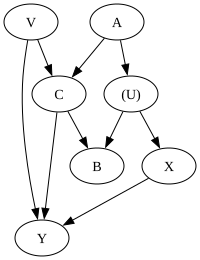

In [ ]:
from causalgraphicalmodels import CausalGraphicalModel

# Define the model
dag = CausalGraphicalModel(
    nodes=["X", "C", "Y", "(U)", "B", "A", "V"],
    edges=[
        ("A", "C"), ("A", "(U)"), 
        ("(U)", "B"), ("(U)", "X"), 
        ("X", "Y"), 
        ("C", "Y"), ("C", "B"),
        ("V", "C"), 
        ("V", "Y"), 
    ]
)

# Draw the model
dag.draw()

In [ ]:
dag.get_all_backdoor_adjustment_sets("X", "Y")

## 6M2

> Sometimes, in order to avoid multicollinearity, people inspect pairwise correlations among predictors before including them in a model. This is a bad procedure, because what matters is the conditional association, not the association before the variables are included in the model. To highlight this, consider the DAG X → Z → Y. Simulate data from this DAG so that the correlation between X and Z is very large. Then include both in a model prediction Y. Do you observe any multicollinearity? Why or why not? What is different from the legs example in the chapter?

```python
import numpy as np
import pandas as pd
import pymc3 as pm
import arviz as az

# Simulate data
np.random.seed(0)
N = 1000
X = np.random.normal(size=N)
Z = X + np.random.normal(size=N)
Y = Z + np.random.normal(size=N)

data = pd.DataFrame({"X": X, "Z": Z, "Y": Y})

# Fit the model
with pm.Model() as model:
    pm.glm.GLM.from_formula("Y ~ X + Z", data)
    trace = pm.sample()

az.summary(trace, var_names=["X", "Z"])
```


In [3]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

# Simulate data
np.random.seed(0)
N = 1000
X = np.random.normal(size=N)
Z = X + np.random.normal(size=N)
Y = Z + np.random.normal(size=N)

data = pd.DataFrame({"X": X, "Z": Z, "Y": Y})

# Fit the model
with pm.Model() as model:
    mu = pm.Normal("mu", 0, 10)
    sigma = pm.HalfNormal("sigma", 10)
    X = pm.Normal("X", mu=mu, sigma=sigma, observed=data["X"])
    Z = pm.Normal("Z", mu=mu, sigma=sigma, observed=data["Z"])
    Y = pm.Normal("Y", mu=mu, sigma=sigma, observed=data["Y"])
    trace = pm.sample(1000, tune=1000)
    
# az.summary(trace, var_names=["mu", "sigma"])

# az.summary(trace, var_names=["X", "Z"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 38 seconds.
